Consider learning the concept of a target "shape", that is given a pair of coordinates,
to determine if the points are IN/OUT of the shape.

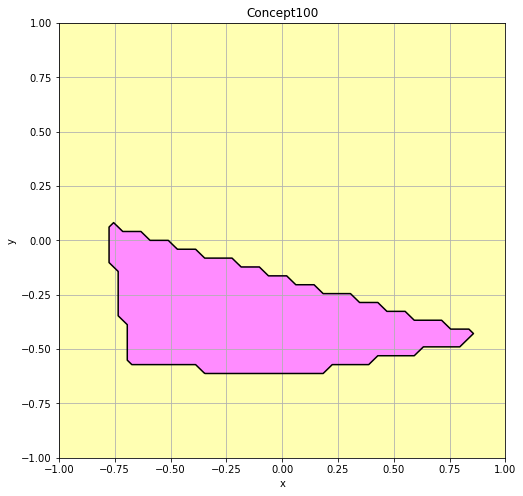

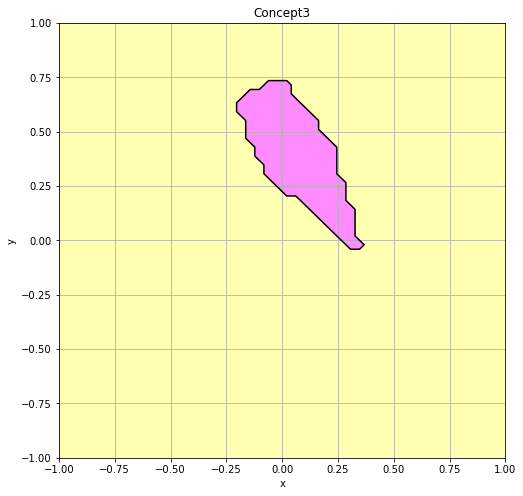

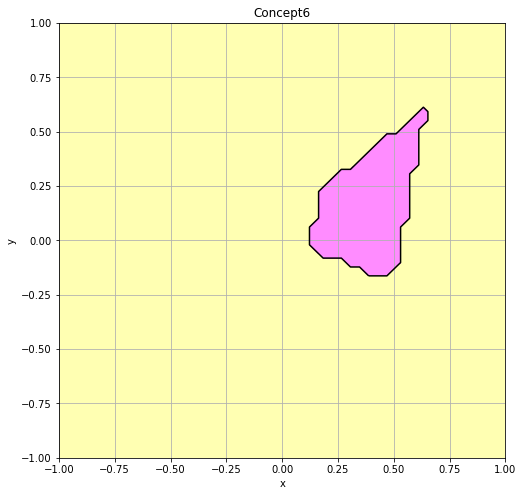

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def sample_target_half_planes(
    num=5,
    dim=2,
    region_min=-1,
    region_max=+1,
    num_samples=10000,
    min_region_ratio=0.05,
    random_seed=42):
    """
    Sample half-planes in D-dimensional space to enclose a region.

    Parameters:
    num: int, the number of half-planes to generate.
    dim: int, the dimensionality of the space.
    region_min: float, the minimum coordinate value of the reference hypercube.
    region_max: float, the maximum coordinate value of the reference hypercube.
    num_samples: int, the number of points sampled from the hypercube to use in the approximation.
    min_region_ratio: float, the minimum ratio of points that must remain in the region after adding a plane.
    random_seed: int, seed for random number generation.

    Returns:
    region_targ: numpy array, each row represents a half-plane with a passing point and a normal vector.
    """
    rng = np.random.RandomState(random_seed)
    
    # Sample a large number of points uniformly in the hypercube
    sample_points = rng.uniform(region_min, region_max, size=(num_samples, dim))
    region_size = region_max - region_min
    
    # Initialize the list to store valid half-planes
    half_planes = []
    
    # Initialize the mask indicating which points are currently in the region
    in_region = np.ones(num_samples, dtype=bool)
    
    for _ in range(num * 10):  # Allow more trials to find valid half-planes
        # Randomly choose a passing point in the hypercube
        pass_point = rng.uniform(region_min + region_size*.1, 
                                 region_max - region_size*.1, size=dim)
        
        # Generate a random normal vector
        normal_vector = rng.uniform(-1, 1, size=dim)
        normal_vector /= np.linalg.norm(normal_vector)  # Normalize
        
        # Check contribution of the new plane
        # Take the bigger chunk (AI cannot think of this)
        new_half_plane1 = np.hstack([pass_point, normal_vector])
        new_in_region1 = points_in_region(sample_points, half_planes + [new_half_plane1])
        new_half_plane2 = np.hstack([pass_point, -normal_vector])
        new_in_region2 = points_in_region(sample_points, half_planes + [new_half_plane2])
        if np.sum(new_in_region1) >= np.sum(new_in_region2):
            new_half_plane = new_half_plane1
            new_in_region = new_in_region1
        else:
            new_half_plane = new_half_plane2
            new_in_region = new_in_region2

        
        # Calculate the ratio of points remaining in the region after adding this plane
        region_ratio = np.sum(new_in_region) / num_samples
        
        if region_ratio >= min_region_ratio \
            and np.count_nonzero(new_in_region!=in_region)>0: # AI didn't get the logic right here.
            half_planes.append(new_half_plane)
            in_region = new_in_region
        
        # Stop if we have found enough valid half-planes
        if len(half_planes) >= num:
            break
    
    # Convert to numpy array
    region_targ = np.array(half_planes)
    
    return region_targ

def points_in_region(points, planes):
    """
    Check if points are inside the region defined by a set of half-planes.

    Parameters:
    points: numpy array, shape (N, D), where N is the number of points and D is the dimensionality.
    planes: list of numpy arrays, each defining a half-plane with a passing point and a normal vector.

    Returns:
    numpy array: Boolean array, where each entry is True if the corresponding point is inside the region.
    """
    in_region = np.ones(points.shape[0], dtype=bool)
    dim = points.shape[1]
    
    for plane in planes:
        pass_point = plane[:dim]
        normal_vector = plane[dim:]
        in_region &= (np.dot(points - pass_point, normal_vector) > 0)
    
    return in_region

from typing import Callable
def visualise_2D_region(in_region_fn: Callable, xy_min=-1, xy_max=+1, 
    num_points=50, title_str="Target Concept"):
    # Generate a mesh grid of points
    x = np.linspace(xy_min, xy_max, num_points)
    y = np.linspace(xy_min, xy_max, num_points)
    xx, yy = np.meshgrid(x, y)
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    # Apply the in_region function to each point in the grid
    in_region = in_region_fn(grid_points)
    
    # Reshape the result back to the grid shape
    in_region = in_region.reshape(xx.shape)
    
    # Plot the region
    fig = plt.figure(figsize=(8, 8))
    plt.contourf(xx, yy, in_region, levels=[0, 0.5, 1], colors=['#FFFF80', '#FF40FF'], alpha=0.6)
    plt.contour(xx, yy, in_region, levels=[0.5], colors='black')
    plt.xlim([xy_min, xy_max])
    plt.ylim([xy_min, xy_max])
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title_str)
    plt.grid(True)
    return fig


# Example usage:
dim = 2
num = 6

concept100 = sample_target_half_planes(
    num=num, dim=dim, region_min=-1, region_max=1, num_samples=10000,
    random_seed=100)
fig = visualise_2D_region(lambda points:points_in_region(points, concept100), title_str="Concept100")

concept3 = sample_target_half_planes(
    num=20, dim=dim, region_min=-1, region_max=1, num_samples=10000,
    random_seed=3)
fig = visualise_2D_region(lambda points:points_in_region(points, concept3), title_str="Concept3")

concept6 = sample_target_half_planes(
    num=num, dim=dim, region_min=-1, region_max=1, num_samples=10000,
    random_seed=6)

fig = visualise_2D_region(lambda points:points_in_region(points, concept6), title_str="Concept6")


Let us check the effect of 

- training samples
- hypothesis set size


In [37]:
# Function to create hypothesis set (rectangles)
def create_rectangle_hypothesis_set(rng, num=1000, xy_min=-1, xy_max=1):
    # Generate x1, y1, x2, y2 for rectangles
    rectangles = []
    for _ in range(num):
        x1 = rng.uniform(xy_min, xy_max)
        y1 = rng.uniform(xy_min, xy_max)
        x2 = rng.uniform(x1, xy_max)  # Ensure x2 > x1
        y2 = rng.uniform(y1, xy_max)  # Ensure y2 > y1
        rectangles.append((x1, y1, x2, y2))
    return rectangles
    

def points_inside_rectangle(points, rectangle):
    x1, y1, x2, y2 = rectangle
    c0 = points[:, 0] >= x1
    c1 = points[:, 0] <= x2
    c2 = points[:, 1] >= y1
    c3 = points[:, 1] <= y2
    return c0 * c1 * c2 * c3

true_concept = concept100
true_fn = lambda X:points_in_region(X, true_concept)
# Learning procedure

# 1. Observe samples
rng = np.random.RandomState(42)
train_num = 100
train_X = rng.uniform(-1, 1, size=(train_num, 2))
train_Y = true_fn(train_X)


# 2. Create a simple and "finite hypothesis" family
hypothesis_set = create_rectangle_hypothesis_set(rng, num=50)
best_hypothesis = None
best_score = 0

# 3. Evaluate the members
scores = []
for rectangle in hypothesis_set:
    predicted_Y = points_inside_rectangle(train_X, rectangle)
    score = np.sum(predicted_Y == train_Y) / len(train_Y)
    scores.append(score)
    if score > best_score:
        best_score = score
        best_hypothesis = rectangle

print("Best Hypothesis (Rectangle):", best_hypothesis)
print("Best Score:", best_score)


Best Hypothesis (Rectangle): (-0.18209411117146024, -0.6534113598583084, 0.0028291957391090305, -0.23965690930910066)
Best Score: 0.91


0 0.91
0
1 0.88
2 0.88
3 0.88
4 0.88
5 0.88
6 0.88
7 0.88
8 0.88
9 0.88
10 0.88
10
11 0.88
12 0.88
13 0.88
14 0.88
15 0.88
16 0.88
17 0.88
18 0.87
19 0.87
20 0.87
20
21 0.86
22 0.86
23 0.86
24 0.86
25 0.86
26 0.86
27 0.86
28 0.85
29 0.85
30 0.84
30
31 0.84
32 0.84
33 0.84
34 0.84
35 0.84
36 0.83
37 0.83
38 0.82
39 0.82
40 0.81
40
41 0.81
42 0.79
43 0.78
44 0.77
45 0.77
46 0.77
47 0.75
48 0.69
49 0.68
49


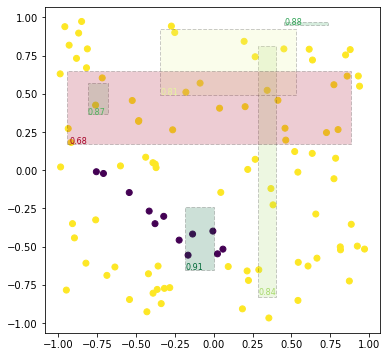

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

norm = plt.Normalize(vmin=np.min(scores), vmax=np.max(scores))
cmap = plt.cm.RdYlGn  # choose any colormap you prefer

ax.scatter(train_X[:, 0], train_X[:, 1], 
            c=1-train_Y) # just to match color, not really mattering

display_num = 5
for i, (h, s) in enumerate(sorted(zip(hypothesis_set, scores), key=lambda x: x[1], reverse=True)):
    if (i % (len(scores) // display_num) != 0) and (i != len(scores)-1): continue
    x1, y1, x2, y2 = h
    width = x2 - x1
    height = y2 - y1
    # Map score to a color using the colormap
    color = cmap(norm(s))
    rect = patches.Rectangle((x1, y1), width, height, edgecolor='k',
                             facecolor=color, alpha=0.2,
                             linestyle="--", linewidth=1)
    
    ax.add_patch(rect)
    ax.text(x1 + 0.01 * width, y1 + 0.01 * height, f"{s:.2f}", color=color, fontsize=8)

plt.show()


Text(0.8820066151242053, 0.9081982287662875, '0.88')

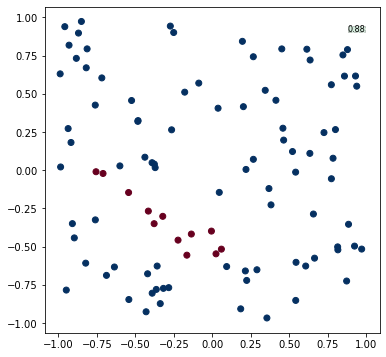

In [52]:
# try 25
h = hypothesis_set[10]
s = scores[10]
predicted_Y = points_inside_rectangle(train_X, h)
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(train_X[:, 0], train_X[:, 1], 
            c=(train_Y==predicted_Y), cmap='RdBu') # just to match color, not really mattering
x1, y1, x2, y2 = h
width = x2 - x1
height = y2 - y1
# Map score to a color using the colormap
color = cmap(norm(s))
rect = patches.Rectangle((x1, y1), width, height, edgecolor='k',
                            facecolor=color, alpha=0.2,
                            linestyle="--", linewidth=1)

ax.add_patch(rect)
ax.text(x1 + 0.01 * width, y1 + 0.01 * height, f"{s:.2f}", color='k', fontsize=8)